# **Project 2: Implementing Simple Linear Regression with Ordinary Least Squares (OLS) and Sum of Squared Errors (SSE) equations**

## **Objective**
In this assignment, you will implement simple linear regression from scratch using only NumPy and base Python. You will:

- Express linear regression in **matrix notation**.
- Compute the **line of best fit** using **OLS**.
- Calculate the **sum of squared errors (SSE)** to evaluate the model.

By the end of this assignment, you will understand how to derive and implement **linear regression** in its fundamental mathematical form.

---

## **Background**

### **Linear Regression Equation**
Simple linear regression is expressed as:


$y = mx + b$


where:
- \( y \) is the **dependent variable** (target),
- \( x \) is the **independent variable** (feature),
- \( m \) is the **slope** (coefficient),
- \( b \) is the **y-intercept**.

---

### **Matrix Form**
We can express the equation in **matrix notation**:

\begin{equation}
Y = X \beta
\end{equation}

where:
- $ Y $ is an $ n \times 1 $ vector of observed values:

  \begin{aligned}
  Y =
  \begin{bmatrix}
  y_1 \\
  y_2 \\
  \vdots \\
  y_n
  \end{bmatrix}
  \end{aligned}

- $ X $ is an $ n \times 2 $ **design matrix**, where the first column consists of ones (for the intercept) and the second column contains the $ x $ values:

  \begin{aligned}
  X =
  \begin{bmatrix}
  1 & x_1 \\
  1 & x_2 \\
  \vdots & \vdots \\
  1 & x_n
  \end{bmatrix}
  \end{aligned}

- $ \beta $ is a $ 2 \times 1 $ vector containing the intercept $b$ and slope $m$:

  \begin{aligned}
  \beta =
  \begin{bmatrix}
  b \\
  m
  \end{bmatrix}
  \end{aligned}

Thus, our model can be rewritten as:

\begin{aligned}
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
&=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
\begin{bmatrix}
b \\
m
\end{bmatrix}
\end{aligned}

---

### **Computing the Best Fit Line Using the ordinary least squares (OLS)**
The **best fit line** is obtained using the **ordinary least squares (OLS)**:

\begin{equation}
\beta = (X^T X)^{-1} X^T Y
\end{equation}

where:
- $ X^T $ is the transpose of $ X $,
- $ (X^T X)^{-1} $ is the **inverse** of $ X^T X $,
- $ X^T Y $ is the product of the transposed $ X $ and $ Y $.
---

### **Sum of Squared Errors (SSE)**
The **sum of squared errors (SSE)** is used to measure how well the regression line fits the data:


\begin{equation}
SSE = \frac{1}{n}\sum_{i=1}^{n} \|y_i - \hat{y}_i\|^2
\end{equation}

where:
- $ y_i $ represents the actual observed values,
- $ \hat{y}_i $ are the predicted values from the model.

Alternatively, using matrix notation:

\begin{equation}
SSE = (Y - X \beta)^T (Y - X \beta)
\end{equation}

where $ Y - X\beta $ represents the **residuals** (differences between actual and predicted values).

---

### **Coding**


### 1. Import Required Libraries
For this lab only use NumPy, Pandas, Matplotlib, and base Python.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 2. Data

* We have a data set that describes 506 suburbs in Boston. Find the documentation for the variables [here](https://islp.readthedocs.io/en/latest/datasets/Boston.html).
* *Goal*: Predict the median value (in $1000s) of houses owned in that suburb.
* *Task*: Use the covariates / independent variables from the data set to create 3 different types of predictive models: single variable, multivariable, and polynomial regression.

**First step: import the data, split into x and y, and turn them into numpy arrays.**

In [2]:
#https://islp.readthedocs.io/en/latest/datasets/Boston.html
df = pd.read_csv('https://raw.githubusercontent.com/intro-stat-learning/ISLP/refs/heads/main/ISLP/data/Boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
# remove the last column because we cannot use the dependent variable in the model
x = df.iloc[:, :-1]
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33


**Begin with a single variable model, selecting the 6th column: 'rm' (average number of rooms per dwelling)**

In [4]:
# Starting with single linear regression
x = df.iloc[:, 5:6]
x.head()

,rm
0,6.575
1,6.421
2,7.185
3,6.998
4,7.147


**Select the target variable that we want to predict: medv (median value of owner-occupied homes in $1000s)**

In [5]:
y = df.iloc[:, -1:]
y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


**Turn both data frame objects into numpy arrays.**

In [6]:
x = x.to_numpy()

In [7]:
y = y.to_numpy()

### 3. Prepare Data in Matrix Form

#### 3a. Convert 𝑥 into matrix form by adding a column of ones for the intercept.

In [8]:
def prepare_matrix(x):
    n = len(x)
    X = np.column_stack((np.ones(n), x))  # Shape (n, 2)
    return X

X = prepare_matrix(x)
Y = y.reshape(-1, 1)  # Reshape y to column vector (aka. nx1 matrix)

#### 3b. Standardize the data. **(2 points)**

In [9]:
# insert your code for standardizing the data
# **remember that currently, your x variable is just the rm column, when you do question 7 and after, make sure every non-label column you use is also standardized**

# standardizing so that X[:, 1] has the mean 0 and std 1
X[:, 1] = (X[:, 1] - np.mean(X[:, 1])) / np.std(X[:, 1])

# to check that the standardization worked:
X[:5, :] 

array([[1.        , 0.41367189],
       [1.        , 0.19427445],
       [1.        , 1.28271368],
       [1.        , 1.01630251],
       [1.        , 1.22857665]])

#### 3c. *Why do we add a column of ones to the 𝑋 matrix?*  **(2 points)**

**Answer:** This column of ones represents $\beta_{0}$, which is the intercept for the regression. Without an intercept column, our regression will have to pass through the origin, which doesn't always accurately reflect the data. So, having a column of ones as our intercept term means we will always have a positive y-intercept and can move our line vertically to best fit the data. 

#### 3d. *Why do we need to standardize our data for linear regression?*  **(2 points)**

**Answer:** We standardize our data to put all of our feature data on the same scale. If we didn't standardize, features with larger values/ranges may automatically be treated as more important in the regression than features with smaller values/ranges. So, we standardize to equalize feature influence. 

For example, with this data set, the `ptratio` and `crim` features are on very different scales because of what they represent. If we did not standardize, the `ptratio` feature would be treated as more important than the `crim` variable, when this isn't necessarily the case.

#### 3e. *Why do we only standardize the 𝑋 matrix?* **(2 points)**

**Answer:** Unlike with standardizing our feature variables (which are stored in the $X$ matrix), standardizing our target variable doesn't improve the model's efficacy. Transforming the feature variable can also makes interpretation more difficult because the output is then on a different scale than what it initially represents. 



### 4. Compute the Best Fit Line Using OLS
#### 4a. Use the formula for Ordinary Least Squares (OLS) Regression to compute the $\beta$ vector. (Hint: Review Lab 4) **(2 points)**

The closed-form OLS solution is calculated from:

\begin{equation}
\beta = (X^T X)^{-1} X^T y
\end{equation}

In [10]:
# Compute beta vector
betas = np.linalg.inv(X.T @ X) @ X.T @ y
print(betas)


[[22.53280632]
 [ 6.38897522]]


#### 4b. *Explain how OLS finds the line of best fit.* **(2 points)**

**Answer:** Most basically, we are using this formula to solve for a $\beta$ matrix (made up of a y-intercept $\beta_{0}$ column and a the slope $\beta_{1}$ column) where $\beta \times$ our feature matrix $X$ is approximately our target matrix $y$. It does this by solving for the $\beta$ values where the difference between the predicted value ($\beta X$) and the actual value ($y$) is the lowest.

To explain more of the math behind it (via Lab 6):

When we are trying to solve for $\beta$ (represented below as $\hat\beta$), we are looking to minimize the residuals $r$ between the predicted ($\hat{y}$) and actual ($y$) values. We come to these values from:

\begin{equation}
\hat{\mathbf{y}}
= X \hat\beta
\quad
\text{and}
\quad
\mathbf{r} = \mathbf{y} - \hat{\mathbf{y}}.
\end{equation}

So, we are trying to find $\beta$ where:

\begin{equation}
\mathbf{y} = \hat{\mathbf{y}}, 
\quad
\text{or,}
\quad
X\beta = \mathbf{y} 
\end{equation}

*(This is expressing that we are trying to find a $\beta$ value that, when multiplied by $X$, approximates $y$ most closely by minimizing the squared euclidian distance between the predicted value $X\beta$ and the actual value $y$)*

To get from this to the OLS closed-form equation:

\begin{gather}
 \text{Multiply by } X^T \text{ on left sides:} \\
  X^T X \beta = X^T Y \\ \\
  \text{Inverse to isolate } \beta \text{:} \\
  (X^T X)^{-1} X^T X \beta = (X^T X)^{-1} X^T Y \\ \\
\end{gather}


Simplifying from here, we get:

\begin{equation}
\beta = (X^{T}X)^{-1} X^{T}y
\end{equation}

...Which is the closed-form OLS regression formula from above.

This makes the key geometric condition $X^T(y - X\hat{\beta}) = 0$, so the residual ($y - X\hat{\beta}$) will always be orthogonal to our projection data $X$.

### 5. Using your computed values for $\beta$, generate the predicted values for the training data.
#### 5a. Use the computed $\beta$ to find the predictions $\hat{Y}$ using matrix multiplication with the design matrix X. **(2 points)**

In [11]:
# Create variable Y_pred (a list of predictions for each suburb)
def predict(X, beta):
    return X @ beta

y_pred = predict(x,betas.T)
print(y_pred)

[[148.15320158  42.00751208]
 [144.68314941  41.0236099 ]
 [161.89821344  45.90478697]
 ...
 [157.18885692  44.56949115]
 [153.08788617  43.40669766]
 [135.87282213  38.52552059]]


#### *5b. What does the y_pred array respresent?* **(2 points)**


**Answer:** the `y_pred` array represents the predicted values we get from multiplying our input matrix $X$ by $\beta$, a matrix where $\beta_{0}$ is the first column and $\beta_{1}$ is the second column. 

### 6. Calculate the normalized Sum of Squared Errors (SSE) for the model.
#### 6a. Compute the SSE to measure how well the regression model fits the training data. **(2 points)**

> **Important:** In this assignment, whenever we say “SSE,” we mean the **normalized** version:
> 
> \begin{equation}
> \text{SSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2
> \end{equation}
> 
> where \(n\) is the number of samples used in that SSE calculation (train or test). This makes train/test errors comparable even when the split sizes differ.


In [12]:
# Compute the **normalized** SSE (SSE/n) and store it in the variable `sse`.
# SSE = (1/n) * sum_i (y_i - yhat_i)^2, where n = number of samples used in this SSE.
# TODO: implement below

SSE = (1/len(y)) * np.sum((y - y_pred)**2)
print(SSE)

14669.636271768131


#### *6b. How does SSE relate to the goodness of fit of the model? In other words, what do we want SSE to be?* **(2 points)**


**Answer:** Since the SSE is the sum of squared errors, and we want to reduce our model's error as much as possible, we want the SSE to be as low as possible. So, a larger SSE corresponds to a worse-fitting model and a smaller SSE corresponds to a better-fitting model.

### 7. Visualize the resulting regression model and line of best fit. Plot the data alongside the line of best fit.

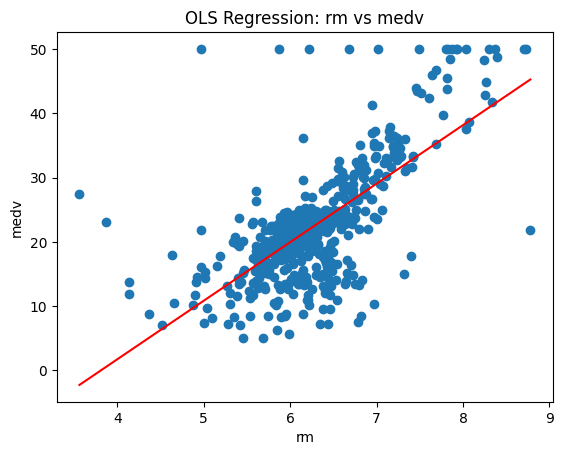

In [13]:
# Scatter plot of the data
plt.scatter(x, y)

# Predicted values from the regression
rm_vals = np.linspace(X[:, 1].min(), X[:, 1].max(), num=1000) 
    # same as in lab (4), we use linspace() to create a continuous range of inputs to more easily plot our regression line
    # also, because we standardized our data, we need to transform it back to use for plotting, and the linspace() function makes that easier
y_hat = betas[0] + betas[1] * rm_vals

# Plot regression line
plt.plot((rm_vals * np.std(x)) + np.mean(x), y_hat,'r')

# Labels
plt.xlabel("rm")
plt.ylabel("medv")
plt.title("OLS Regression: rm vs medv")

plt.show()

### 8. The above plot looks at the relationship between *rm* (an independent variable) and *mdev* (the dependent variable we are trying to predict). Create a single ordinary least squares (OLS) regression with a different independent variable (other than *rm*) from our data set. Once you have your predictions, plot the line of best fit with your chosen independent variable on the x-axis and *mdev* on the y-axis. **(2 points)**

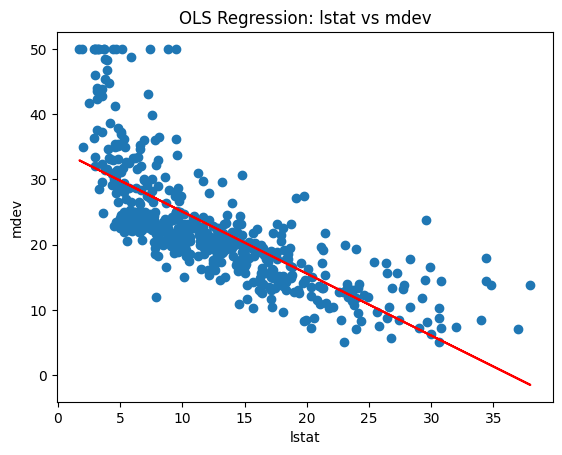

In [14]:
### implement your single regression model here

x = df['lstat']
y = df['medv']

# Create X matrix with intercept
X = np.column_stack((np.ones(len(x)), x))

# Compute OLS coefficients
betas = np.linalg.inv(X.T @ X) @ X.T @ y

# Predictions
y_hat = betas[0] + betas[1] * x

# Plot
plt.scatter(x, y)
plt.plot(x, y_hat, 'r')

plt.xlabel("lstat")
plt.ylabel("mdev")
plt.title("OLS Regression: lstat vs mdev")

plt.show()

### 9.
To this point, you've trained a single variable linear regression on just the training data. This tells us how the model will perform on data we already have, but not on actual data we recieve in the future. To get a better understanding of how the data will run on unseen data, we need to split our data into training and testing data.


Now, train a single linear regression model using a train/test split. Identify how the mdoel does on the training vs testing data.

#### 9a. Split the data into a training and test split. In the training set, keep 80% of the observations. In the test set, keep the other 20% of observations. **(2 points)**

In [15]:
# Split into Training and Testing Sets (80% of the data should be in your training array and 20% of your data should be in your test array)
from sklearn.model_selection import train_test_split

# independent variable
X = df[['rm']]   # keep as 2D

# dependent variable
y = df['medv']

# 80% training, 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#### 9b. With your training data, train the model by minimizing the Sum of Squared Errors (normalized SSE (SSE/n)). You will have one coefficient for the intercept term $(\beta_0)$ and another for your chosen independent variable ($\beta_1$). **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [16]:
# Train model by minimizing the (normalized) SSE.
# Note: dividing SSE by n does NOT change the optimal coefficients (it only rescales the objective).
# TODO: implement training below
# Train model by minimizing the normalized SSE on the TRAIN split

# add intercept column to training data
X_train_matrix = np.column_stack((np.ones(len(X_train)), X_train))

# compute OLS coefficients
betas = np.linalg.inv(X_train_matrix.T @ X_train_matrix) @ X_train_matrix.T @ y_train

beta_0 = betas[0]
beta_1 = betas[1]

print("beta_0:", beta_0)
print("beta_1:", beta_1)



beta_0: -36.24631889813803
beta_1: 9.34830140649774


#### 9c. Using your trained model ($\beta$ coefficients), calculate your predictions on the training data set. Compare your predictions with the true values of *mdev* in the train set by computing the normalized SSE (SSE/n). Report your value of normalized SSE (SSE/n). **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [17]:
# Evaluate your trained model on the training data.
# Compute the **normalized** SSE (SSE/n) on the TRAIN split.
# TODO: compute sse_train below

y_hat_train = beta_0 + beta_1 * X_train.values.flatten()
sse_train = (1 / len(y_train)) * np.sum((y_train - y_hat_train) ** 2)

print("Training normalized SSE:", sse_train)


Training normalized SSE: 42.99661556265404


#### 9d. Now use your trained model to calculate your predictions on the test data set. Compute the normalized SSE (SSE/n) on the test data set. **(5 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [18]:
# Evaluate your trained model on the test data.
# Compute the **normalized** SSE (SSE/n) on the TEST split.
# TODO: compute sse_test below

# test predictions
y_hat_test = beta_0 + beta_1 * X_test['rm']

# normalized SSE on test set
sse_test = (1 / len(y_test)) * np.sum((y_test - y_hat_test) ** 2)

print("Test normalized SSE:", sse_test)

Test normalized SSE: 46.14477534731728


#### 9e. How does the SSE on the test set compare to the SSE on the training set? **(2 points)**

**Answer:** The normalized SSE on the test set is similar to the SSE on the training set. This indicates that the model performs similarly on unseen data as it does on the training data, suggesting that the model is not significantly overfitting and generalizes reasonably well.



### 9f. Plot (like in Question 7) your line of best fit over your training data. **(2 points)**

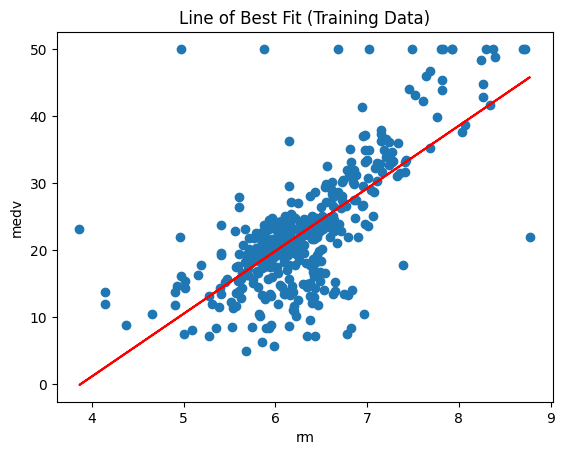

In [19]:
# Plot here


plt.scatter(X_train, y_train)

# predicted line
y_hat_train = beta_0 + beta_1 * X_train.values.flatten()

plt.plot(X_train, y_hat_train, 'r')

plt.xlabel("rm")
plt.ylabel("medv")
plt.title("Line of Best Fit (Training Data)")

plt.show()



### 9g. Plot (like in Question 7) your line of best fit over your test data. **(2 points)**

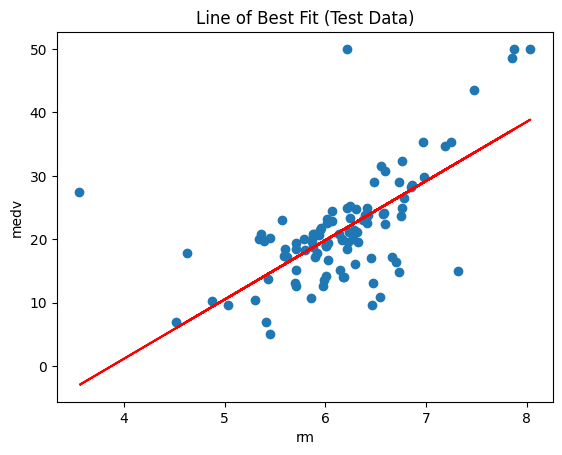

In [20]:
# Plot here


plt.scatter(X_test, y_test)

# predicted line
y_hat_test = beta_0 + beta_1 * X_test.values.flatten()

plt.plot(X_test, y_hat_test, 'r')

plt.xlabel("rm")
plt.ylabel("medv")
plt.title("Line of Best Fit (Test Data)")

plt.show()


### 10. The models you have created thus far are only examples of single ordinary least squares. What if we want to include more than one independent variable in our prediction? Train a multiple linear regression model which incorporates all of the available independent variables in the data set. Using your model, predict the median house value. Compare your results on the training data set vs the test data set again. **(10 points)**

> Reminder: when comparing train vs test error, use **normalized SSE = (1/n)·∑(y-ŷ)^2**.


Multiple Regression Training normalized SSE: 22.60428647941742
Multiple Regression Test normalized SSE: 22.77770856386606


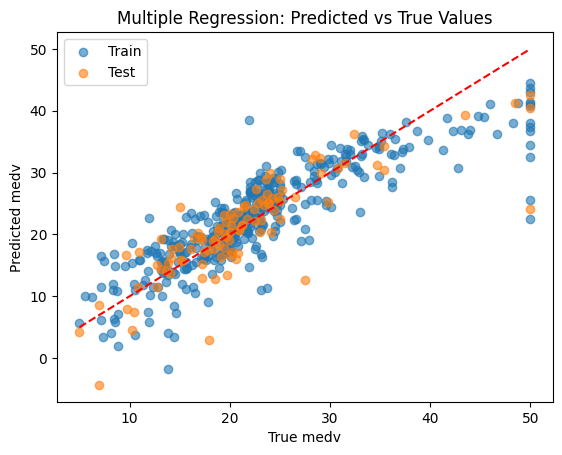

In [21]:
### Modify your code for multiple linear regression (use all non-label columns available to train a model to predict median house value)
#Hint: remove the last column because we cannot use the dependent variable in the model
#TODO: implement your multiple regression model here


#Remove last column (label) to get feature matrix
X = df.iloc[:, :-1].to_numpy()
y = df.iloc[:, -1].to_numpy()

#Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Standardize all feature columns, fit on train only
for i in range(X_train.shape[1]):
    mean = np.mean(X_train[:, i])
    std = np.std(X_train[:, i])
    X_train[:, i] = (X_train[:, i] - mean) / std
    X_test[:, i] = (X_test[:, i] - mean) / std  # use train mean and std to standardize test set

#Add bias column
X_train = prepare_matrix(X_train)
X_test = prepare_matrix(X_test)

#Compute betas
betas_multi = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

#Predictions
y_pred_train = predict(X_train, betas_multi)
y_pred_test = predict(X_test, betas_multi)

#Normalized SSE
sse_train_multi = (1 / len(y_train)) * np.sum((y_train - y_pred_train) ** 2)
sse_test_multi = (1 / len(y_test)) * np.sum((y_test - y_pred_test) ** 2)

print("Multiple Regression Training normalized SSE:", sse_train_multi)
print("Multiple Regression Test normalized SSE:", sse_test_multi)

#plot multiple regression predictions vs true values for train and test sets
plt.scatter(y_train, y_pred_train, alpha=0.6, label="Train")
plt.scatter(y_test, y_pred_test, alpha=0.6, label="Test")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # line y=x for reference
plt.xlabel("True medv")
plt.ylabel("Predicted medv")
plt.title("Multiple Regression: Predicted vs True Values")
plt.legend()
plt.show()










### 11. The model you made in the previous question only had linear terms of our features. Sometimes, we want to capture more complicated relationships between variables. To add more complexity to our model, experiment with differnet polynomial models. For each model, try to think about whether you may be overfitting or underfitting to the training data. Again, compare your performnance on the training data vs the testing data.

#### 11a. Modify the design matrix to include polynomial terms of degree 2. (Hint: add squared values of existing columns to the deign matrix X). Calculate the normalized SSE (SSE/n) on the training and testing data sets. **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


Polynomial Regression Training normalized SSE: 15.939992168535818
Polynomial Regression Test normalized SSE: 14.042431309172288


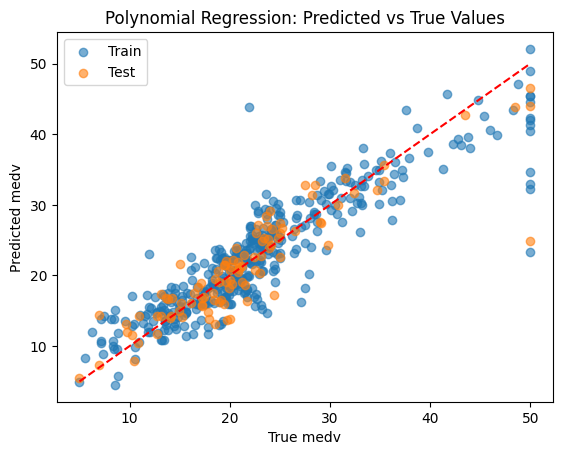

In [22]:
### Modify for polynomial regression (degree 2)
# Reminder: when reporting SSE in this section, use **normalized SSE** = sum((y - yhat)^2) / n.
# TODO: build your degree-2 design matrix, fit coefficients, and compute train/test normalized SSE.

#Build degree-2 design matrix
X_train_features = X_train[:, 1:]  # exclude bias column
X_test_features = X_test[:, 1:]    # exclude bias column
X_train_poly = np.column_stack((X_train, X_train_features ** 2))
X_test_poly = np.column_stack((X_test, X_test_features ** 2))

#Standardize the new polynomial features using the mean and std from the original features
for i in range(1, X_train_poly.shape[1]):  # start from 1 to skip bias column
    mean = np.mean(X_train_poly[:, i])
    std = np.std(X_train_poly[:, i])
    X_train_poly[:, i] = (X_train_poly[:, i] - mean) / std
    X_test_poly[:, i] = (X_test_poly[:, i] - mean) / std  # use train mean and std to standardize test set

#Compute betas
betas_poly = np.linalg.inv(X_train_poly.T @ X_train_poly) @ X_train_poly.T @ y_train

#Predictions
y_pred_train_poly = predict(X_train_poly, betas_poly)
y_pred_test_poly = predict(X_test_poly, betas_poly)

#Normalized SSE
sse_train_poly = (1 / len(y_train)) * np.sum((y_train - y_pred_train_poly) ** 2)
sse_test_poly = (1 / len(y_test)) * np.sum((y_test - y_pred_test_poly) ** 2)

print("Polynomial Regression Training normalized SSE:", sse_train_poly)
print("Polynomial Regression Test normalized SSE:", sse_test_poly)

#plot predicted vs true values for train and test sets
plt.scatter(y_train, y_pred_train_poly, alpha=0.6, label="Train")
plt.scatter(y_test, y_pred_test_poly, alpha=0.6, label="Test")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # line y=x for reference
plt.xlabel("True medv")
plt.ylabel("Predicted medv")
plt.title("Polynomial Regression: Predicted vs True Values")
plt.legend()
plt.show()


#### 11aa. After fitting your degree-2 model, make a quick visualization for sanity-checking. **(5 points)**

Using the **same single feature** you used back in Q9 (your chosen independent variable), plot:
1. The original data points \((x, y)\) as a scatter plot.
2. The fitted quadratic curve \(\hat{y} = a + bx + cx^2\) on top of the scatter plot.

> Tip: sort the x-values before plotting the curve so the line looks smooth.



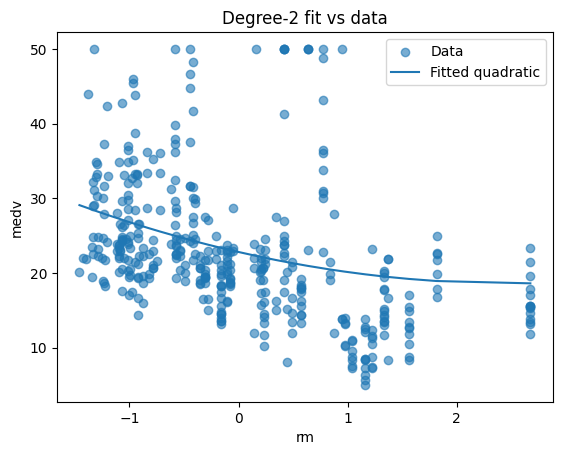

In [23]:
# 11aa: Plot datapoints and fitted quadratic yhat = a + b x + c x^2 (for your chosen feature from Q9)
# TODO: Fill in `x_feature`, `y_true`, and the coefficients a, b, c from your degree-2 fit.

import numpy as np
import matplotlib.pyplot as plt


# x_feature = ...   # shape (n,)
x_feature = X_train[:,5]
# y_true = ...      # shape (n,)
y_true = y_train
# a, b, c = ...     # scalars (from your fitted quadratic on this feature)
a = betas_poly[0]  # intercept
b = betas_poly[1]  # linear term coefficient for the chosen feature
c = betas_poly[X_train.shape[1] + 1]  # quadratic termcoefficient for the chosen feature (index depends on how you constructed your design matrix)


# Make a smooth curve
x_sorted = np.sort(x_feature)
y_curve = a + b * x_sorted + c * (x_sorted ** 2)

plt.figure()
plt.scatter(x_feature, y_true, alpha=0.6, label="Data")
plt.plot(x_sorted, y_curve, label="Fitted quadratic")
plt.xlabel("rm")
plt.ylabel("medv")
plt.title("Degree-2 fit vs data")
plt.legend()
plt.show()



#### 11b. To test how our model performs as we change the degree of our model. Train models of degree 1 to degree 8. This will result in 8 different models.  For each model you create, save the Sum of Squared Errors (normalized SSE (SSE/n)) on the training and test data set respectively. We will use them for the next step to plot how they change as the model becomes more complex. **(20 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


In [24]:
### Fit polynomial models of degrees 1-8, save training and testing errors
# Reminder: store **normalized** SSE values for each split:
#   sse_k_train = sum((y_train - yhat_train)^2) / len(y_train)
#   sse_k_test  = sum((y_test  - yhat_test )^2) / len(y_test)
# TODO: implement loop over degrees below and save errors for plotting.
train_errors = []
test_errors = []

for degree in range(1, 9):
    #Build design matrix with polynomial terms up to the current degree
    X_train_poly = X_train.copy()
    X_test_poly = X_test.copy()

    for d in range(2, degree + 1):
        X_train_d = X_train[:, 1:] ** d  # compute degree d terms for features (exclude bias)
        X_test_d = X_test[:, 1:] ** d
        
        #Standardize each degrees term
        for i in range(X_train_d.shape[1]):
            mean = np.mean(X_train_d[:, i])
            std = np.std(X_train_d[:, i])
            X_train_d[:, i] = (X_train_d[:, i] - mean) / std
            X_test_d[:, i] = (X_test_d[:, i] - mean) / std  # use train mean and std to standardize test set
        
        X_train_poly = np.column_stack((X_train_poly, X_train_d))
        X_test_poly = np.column_stack((X_test_poly, X_test_d))

    #Compute betas
    betas_poly = np.linalg.pinv(X_train_poly) @ y_train

    #Predictions
    y_pred_train_poly = predict(X_train_poly, betas_poly)
    y_pred_test_poly = predict(X_test_poly, betas_poly)

    #Normalized SSE
    sse_train_poly = (1 / len(y_train)) * np.sum((y_train - y_pred_train_poly) ** 2)
    sse_test_poly = (1 / len(y_test)) * np.sum((y_test - y_pred_test_poly) ** 2)

    train_errors.append(sse_train_poly)
    test_errors.append(sse_test_poly)




### Overfitting

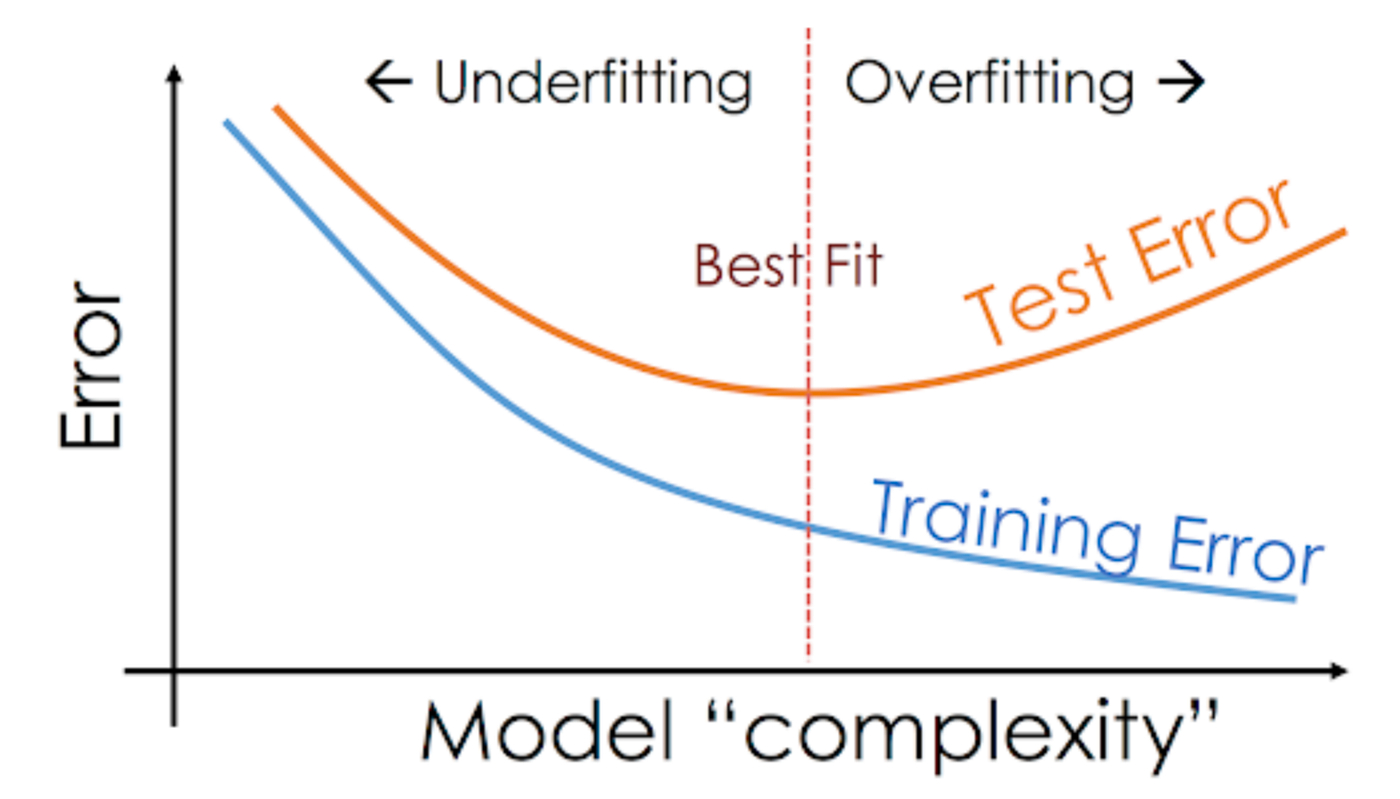

#### 11c. Using the training and testing normalized SSE (SSE/n) you calculated in the previous question, plot the errors for each model complexity. In this plot, the x-axis will be the model complexity (degree of the model) and the y-axis will be the normalized SSE (SSE/n) you calculated. What can you determine from this plot? How does the error on the training data set compare to the error on the testing data set as the degree of the model increases? **(10 points)**

> Reminder: use **SSE = (1/n)·∑(y-ŷ)^2** with n equal to the sample size for that split.


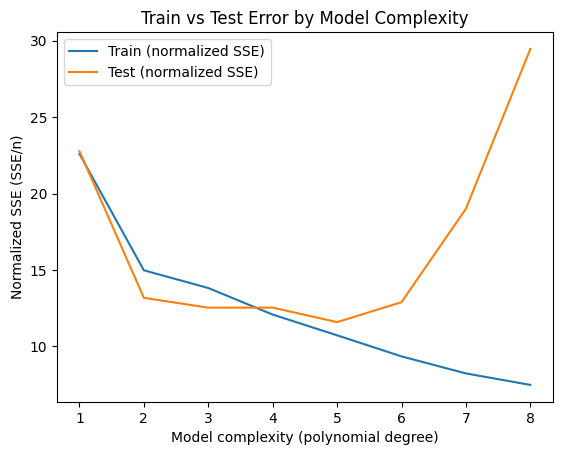

In [25]:
###Graph training and testing errors on same line plot to show overfitting
#After you correct SSE everywhere (use normalized SSE), make sure this plot renders and matches the reference image above.
#TODO: replace `degrees`, `train_errors`, `test_errors` with your actual arrays/lists.

import matplotlib.pyplot as plt


# Example placeholders (replace with your computed values)
# degrees = list(range(1, 9))
# train_errors = [...]
# test_errors = [...]
degrees = list(range(1, 9))


plt.figure()
plt.plot(degrees, train_errors, label="Train (normalized SSE)")
plt.plot(degrees, test_errors, label="Test (normalized SSE)")
plt.xlabel("Model complexity (polynomial degree)")
plt.ylabel("Normalized SSE (SSE/n)")
plt.title("Train vs Test Error by Model Complexity")
plt.legend()
plt.show()

